In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing Dataset

In [2]:
ogdf = pd.read_csv("credit_fraud.csv")

In [3]:
ogdf

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1
...,...,...,...,...,...,...,...,...,...,...
32295,52.0,7033.85,7657.07,40.0,0.0,6.0,0.0,304.7,8.2,0
32296,48.0,8974.84,22418.91,49.0,0.0,18.0,0.0,3683.3,6.4,1
32297,70.0,5240.01,43444.14,41.0,0.0,9.0,0.0,3836.7,5.1,0
32298,28.0,8717.43,12451.13,11.0,0.0,0.0,0.0,1620.7,9.4,0


In [4]:
df = ogdf

# Data Cleaning

In [5]:
df.shape

(32300, 10)

In [6]:
df.columns

Index(['age', 'transaction_amount', 'account_balance',
       'num_transactions_today', 'is_foreign_transaction', 'transaction_hour',
       'prev_fraud_flag', 'merchant_distance_km', 'merchant_risk_score',
       'is_fraud'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     31656 non-null  object 
 1   transaction_amount      31653 non-null  float64
 2   account_balance         31655 non-null  float64
 3   num_transactions_today  31654 non-null  float64
 4   is_foreign_transaction  31649 non-null  float64
 5   transaction_hour        31657 non-null  float64
 6   prev_fraud_flag         31654 non-null  float64
 7   merchant_distance_km    31657 non-null  float64
 8   merchant_risk_score     31656 non-null  float64
 9   is_fraud                32300 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 2.5+ MB


In [8]:
df.isnull().sum()

age                       644
transaction_amount        647
account_balance           645
num_transactions_today    646
is_foreign_transaction    651
transaction_hour          643
prev_fraud_flag           646
merchant_distance_km      643
merchant_risk_score       644
is_fraud                    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(298)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(32002, 10)

In [12]:
df["age"].unique()

array(['41.0', '49.0', '38.0', '61.0', '-10.0', '42.0', nan, '50.0',
       '57.0', '71.0', '62.0', '37.0', '72.0', '54.0', '65.0', '32.0',
       '33.0', '28.0', '25.0', '53.0', '19.0', '29.0', '35.0', '24.0',
       '55.0', '74.0', '51.0', '58.0', '60.0', '69.0', '22.0', '47.0',
       '59.0', '46.0', '18.0', '43.0', '21.0', '36.0', '70.0', '39.0',
       '40.0', '63.0', '44.0', '52.0', '27.0', '64.0', '73.0', '45.0',
       '20.0', '48.0', '56.0', '30.0', '37.0_err', '26.0', '34.0', '67.0',
       '68.0', '23.0', '66.0', '33.0_err', '31.0', '74.0_err', '22.0_err',
       '47.0_err', 'nan_err', '24.0_err', '46.0_err', '64.0_err',
       '73.0_err', '54.0_err', '20.0_err', '41.0_err', '34.0_err',
       '57.0_err', '23.0_err', '66.0_err', '59.0_err', '25.0_err',
       '56.0_err', '27.0_err', '55.0_err', '68.0_err', '44.0_err',
       '49.0_err', '45.0_err', '52.0_err', '30.0_err', '21.0_err',
       '43.0_err', '61.0_err', '35.0_err', '32.0_err', '65.0_err',
       '69.0_err', '58.0_

In [13]:
df["age"] = df["age"].str.replace('_err', '', regex=False)

In [14]:
df['age'].unique()

array(['41.0', '49.0', '38.0', '61.0', '-10.0', '42.0', nan, '50.0',
       '57.0', '71.0', '62.0', '37.0', '72.0', '54.0', '65.0', '32.0',
       '33.0', '28.0', '25.0', '53.0', '19.0', '29.0', '35.0', '24.0',
       '55.0', '74.0', '51.0', '58.0', '60.0', '69.0', '22.0', '47.0',
       '59.0', '46.0', '18.0', '43.0', '21.0', '36.0', '70.0', '39.0',
       '40.0', '63.0', '44.0', '52.0', '27.0', '64.0', '73.0', '45.0',
       '20.0', '48.0', '56.0', '30.0', '26.0', '34.0', '67.0', '68.0',
       '23.0', '66.0', '31.0', 'nan'], dtype=object)

In [15]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [16]:
df['age'].unique()

array([ 41.,  49.,  38.,  61., -10.,  42.,  nan,  50.,  57.,  71.,  62.,
        37.,  72.,  54.,  65.,  32.,  33.,  28.,  25.,  53.,  19.,  29.,
        35.,  24.,  55.,  74.,  51.,  58.,  60.,  69.,  22.,  47.,  59.,
        46.,  18.,  43.,  21.,  36.,  70.,  39.,  40.,  63.,  44.,  52.,
        27.,  64.,  73.,  45.,  20.,  48.,  56.,  30.,  26.,  34.,  67.,
        68.,  23.,  66.,  31.])

In [17]:
df.loc[df['age']<0, "age"] = np.nan
df['age'].unique()

array([41., 49., 38., 61., nan, 42., 50., 57., 71., 62., 37., 72., 54.,
       65., 32., 33., 28., 25., 53., 19., 29., 35., 24., 55., 74., 51.,
       58., 60., 69., 22., 47., 59., 46., 18., 43., 21., 36., 70., 39.,
       40., 63., 44., 52., 27., 64., 73., 45., 20., 48., 56., 30., 26.,
       34., 67., 68., 23., 66., 31.])

In [18]:
df['age'] = df["age"].fillna(df['age'].median())

In [19]:
df['age'].unique()

array([41., 49., 38., 61., 46., 42., 50., 57., 71., 62., 37., 72., 54.,
       65., 32., 33., 28., 25., 53., 19., 29., 35., 24., 55., 74., 51.,
       58., 60., 69., 22., 47., 59., 18., 43., 21., 36., 70., 39., 40.,
       63., 44., 52., 27., 64., 73., 45., 20., 48., 56., 30., 26., 34.,
       67., 68., 23., 66., 31.])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32002 entries, 0 to 32060
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     32002 non-null  float64
 1   transaction_amount      31362 non-null  float64
 2   account_balance         31362 non-null  float64
 3   num_transactions_today  31362 non-null  float64
 4   is_foreign_transaction  31362 non-null  float64
 5   transaction_hour        31362 non-null  float64
 6   prev_fraud_flag         31362 non-null  float64
 7   merchant_distance_km    31362 non-null  float64
 8   merchant_risk_score     31362 non-null  float64
 9   is_fraud                32002 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 2.7 MB


### Immuting Missing Values

In [21]:
from sklearn.impute import SimpleImputer

In [22]:
imputer = SimpleImputer(strategy="median")

In [23]:
cols = [
    'transaction_amount',
    'account_balance',
    'num_transactions_today',
    'is_foreign_transaction',
    'transaction_hour',
    'prev_fraud_flag',
    'merchant_distance_km',
    'merchant_risk_score'
]

df[cols] = imputer.fit_transform(df[cols])

In [24]:
df.isna().sum()

age                       0
transaction_amount        0
account_balance           0
num_transactions_today    0
is_foreign_transaction    0
transaction_hour          0
prev_fraud_flag           0
merchant_distance_km      0
merchant_risk_score       0
is_fraud                  0
dtype: int64

In [25]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,11.0,0.0,4366.7,9.7,1


In [26]:
intcols = [ 'age', 'num_transactions_today', 'is_foreign_transaction', 'transaction_hour']

In [27]:
df[intcols] = df[intcols].astype(int)

# EDA

In [28]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41,2453.81,12686.50,21,0,9,0.0,2438.2,5.2,0
1,49,1574.12,36337.02,37,0,4,0.0,2967.1,8.4,1
2,38,14897.42,23295.64,21,0,0,0.0,4703.6,3.7,0
3,38,9927.23,38586.08,46,0,17,0.0,4281.2,5.5,1
4,61,12914.13,2013.73,34,0,11,0.0,4366.7,9.7,1


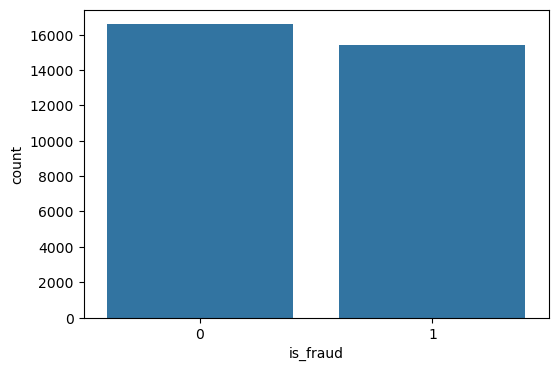

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_fraud')
plt.show()

In [30]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

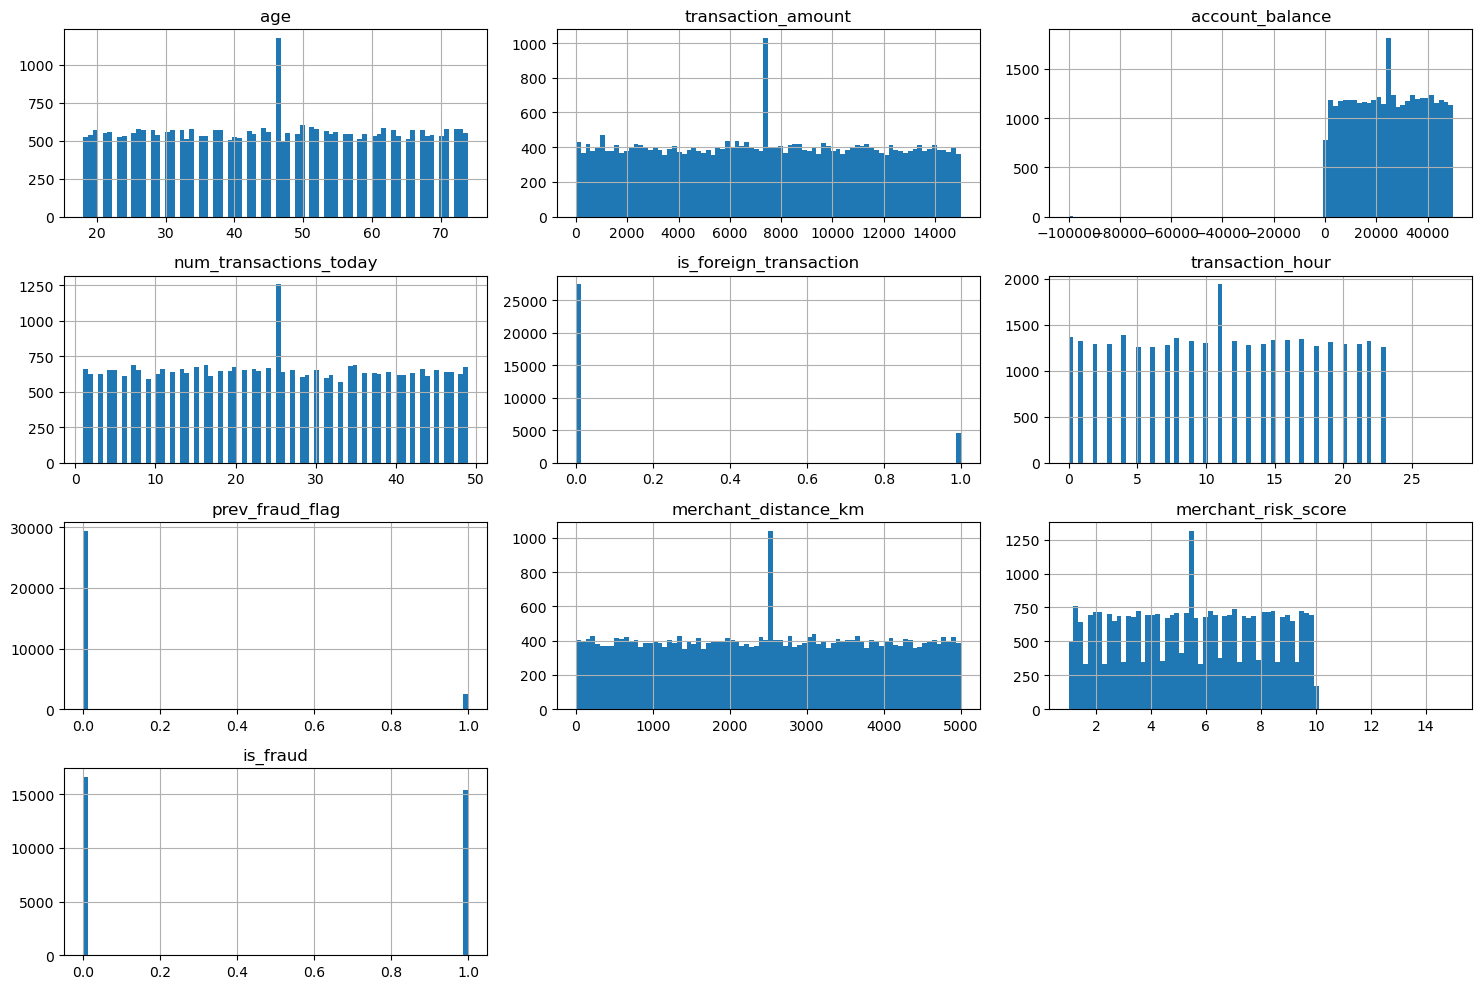

In [31]:
df[num_cols].hist(figsize=(15,10), bins =80)
plt.tight_layout()

<Axes: xlabel='merchant_distance_km', ylabel='Count'>

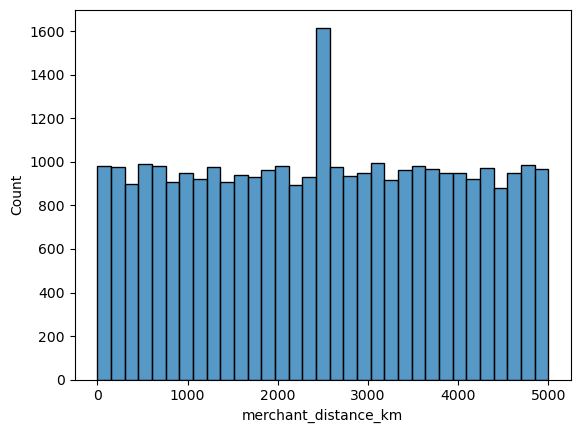

In [32]:
sns.histplot(df['merchant_distance_km'])

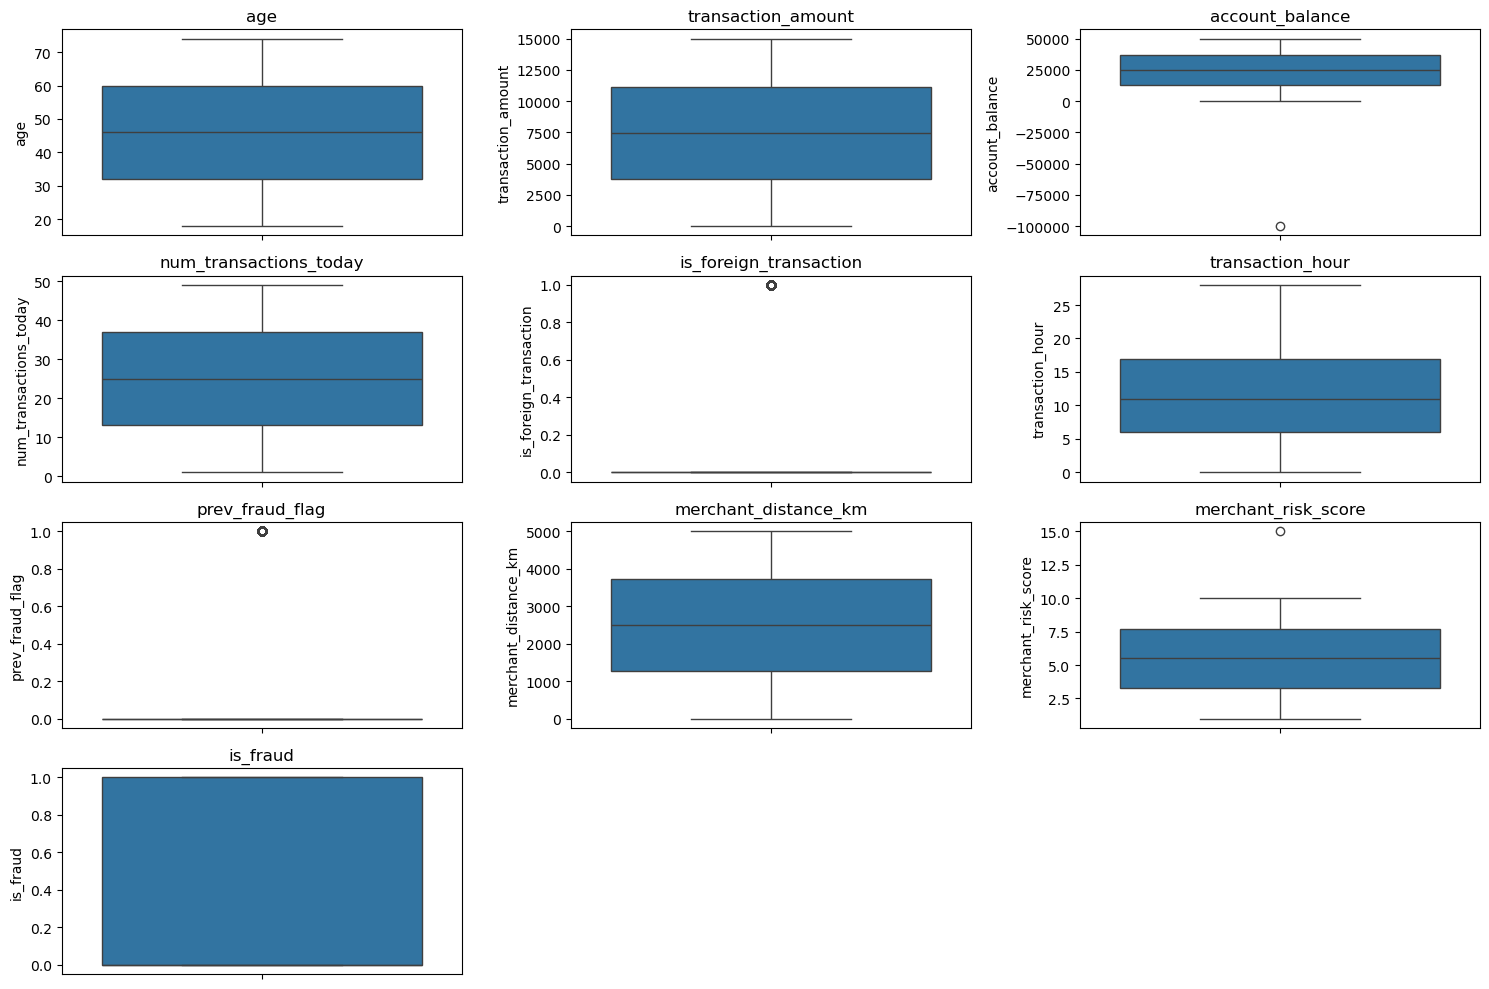

In [33]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [34]:
(df['account_balance'] < 0).sum()

np.int64(1)

In [35]:
df[df['account_balance'] < 0]

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
25,19,11379.89,-99999.0,17,0,9,0.0,4837.8,7.7,1


In [36]:
df = df[df['account_balance'] >0]

In [37]:
df.shape

(32001, 10)

<Axes: ylabel='account_balance'>

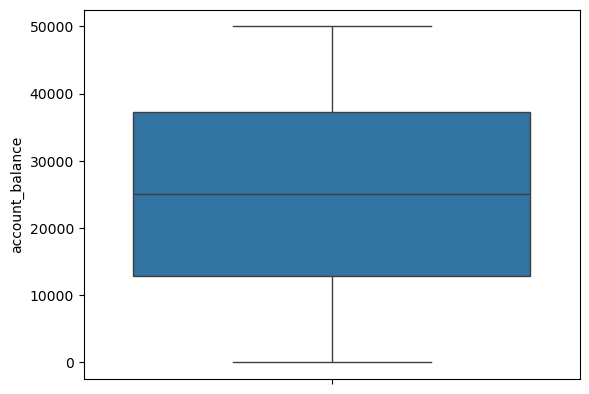

In [38]:
sns.boxplot(df['account_balance'])

In [39]:
df.corr()["is_fraud"]

age                      -0.096996
transaction_amount        0.205578
account_balance          -0.004836
num_transactions_today    0.121689
is_foreign_transaction    0.236840
transaction_hour          0.075307
prev_fraud_flag           0.257064
merchant_distance_km      0.257224
merchant_risk_score       0.216605
is_fraud                  1.000000
Name: is_fraud, dtype: float64

<Axes: >

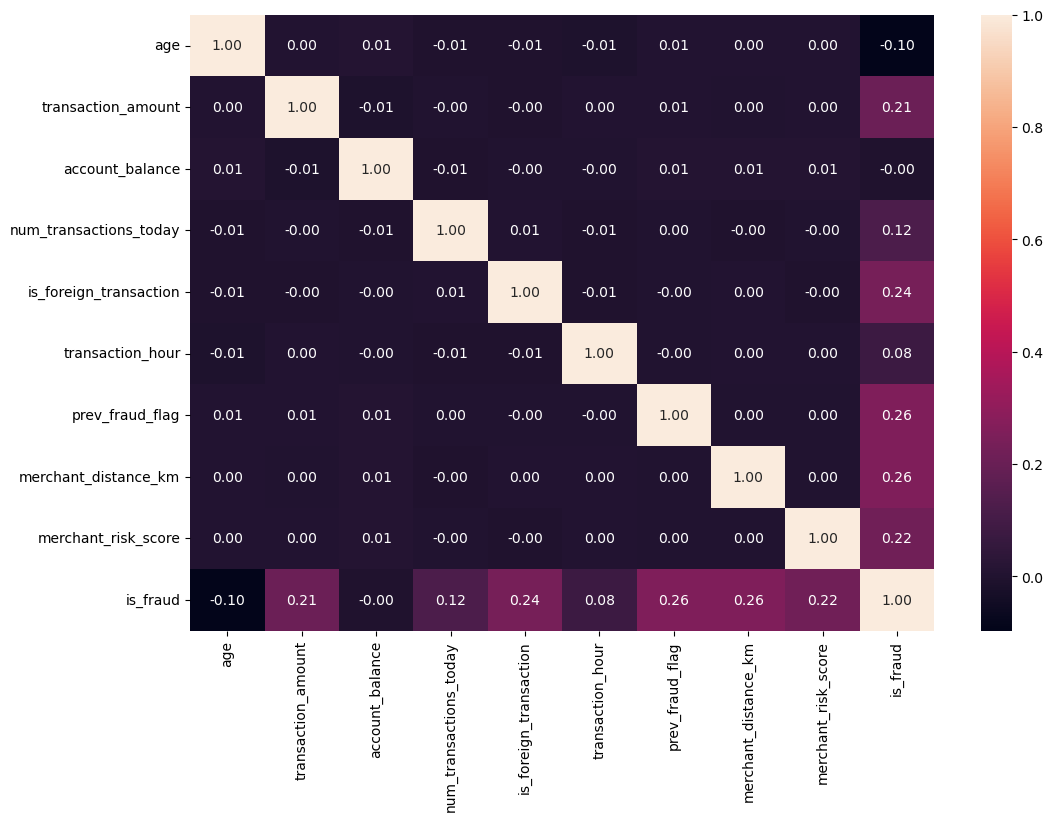

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,fmt='.2f')

<Axes: xlabel='is_fraud', ylabel='transaction_amount'>

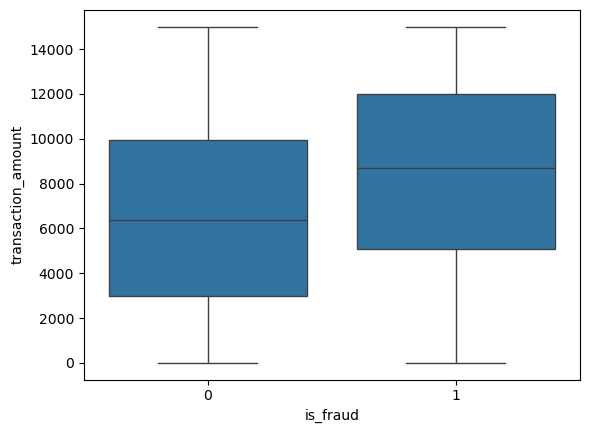

In [41]:
sns.boxplot(x='is_fraud',
            y='transaction_amount',
            data=df)

<Axes: xlabel='is_fraud', ylabel='age'>

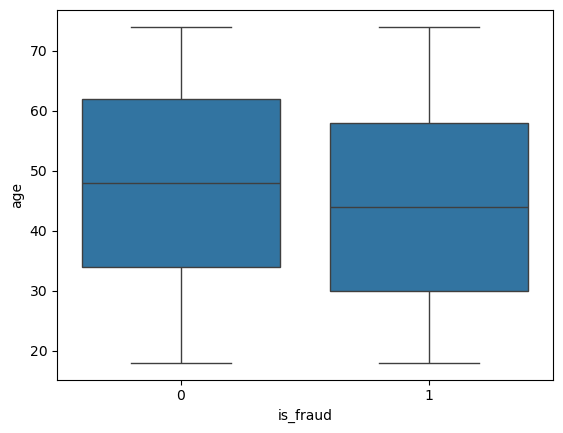

In [42]:
sns.boxplot(x='is_fraud',
            y='age',
            data=df)

<Axes: xlabel='is_fraud', ylabel='account_balance'>

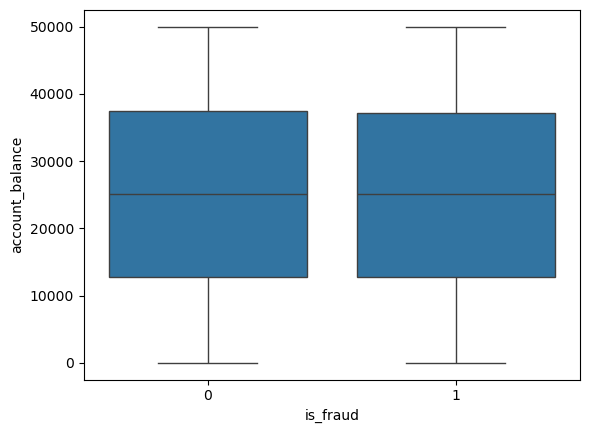

In [43]:
sns.boxplot(x='is_fraud',
            y='account_balance',
            data=df)

<Axes: xlabel='is_fraud', ylabel='merchant_distance_km'>

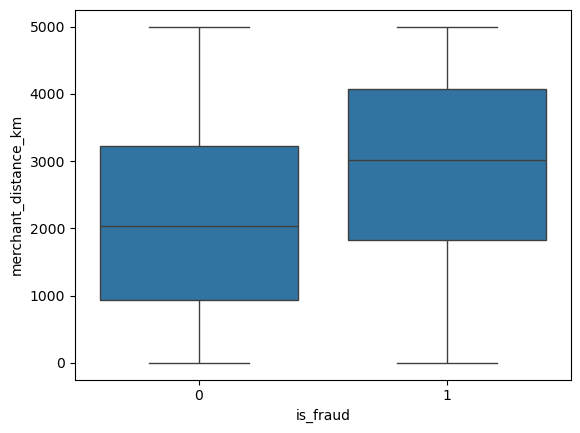

In [44]:
sns.boxplot(x='is_fraud',
            y='merchant_distance_km',
            data=df)

<Axes: xlabel='is_fraud', ylabel='merchant_risk_score'>

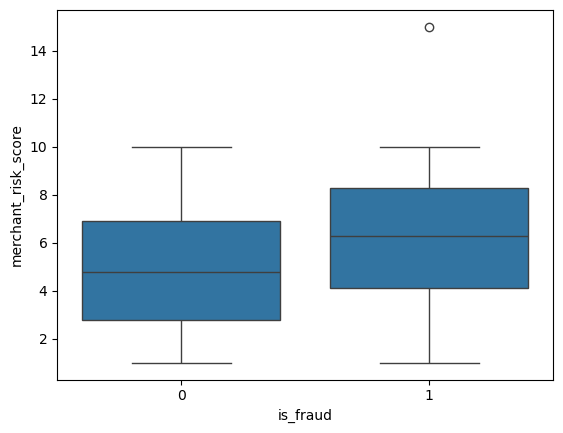

In [45]:
sns.boxplot(x='is_fraud',
            y='merchant_risk_score',
            data=df)

<Axes: ylabel='merchant_risk_score'>

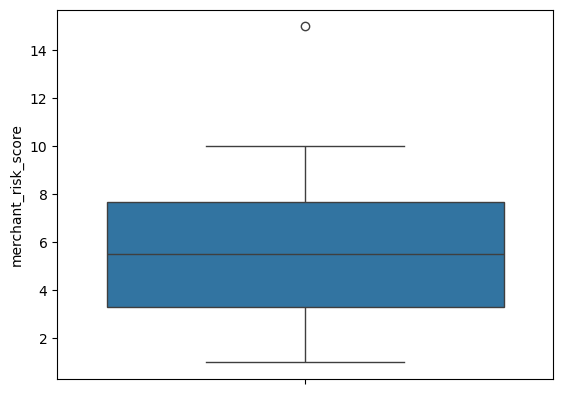

In [46]:
sns.boxplot(df['merchant_risk_score'])

In [47]:
df['merchant_risk_score'].unique()

array([ 5.2,  8.4,  3.7,  5.5,  9.7,  1.1,  9.8,  7.9,  3.5,  6.7,  9.2,
        4. ,  8.8,  1.8, 15. ,  5. ,  4.3,  6.1,  6.2,  7. ,  8.1,  2.3,
        2.7,  1. ,  8.2,  1.9,  1.7,  7.3,  4.6,  1.4,  2.2,  4.2,  9.1,
        5.4,  8.5,  1.3,  4.7,  1.5,  1.6,  3.8,  7.7,  7.4,  3.1,  2.8,
        8. ,  4.1,  8.3,  5.6,  5.9,  5.8,  5.7,  6.5,  5.3,  7.8,  9.4,
        4.9,  7.2,  6. ,  6.8,  1.2,  3.4,  7.1,  6.3,  3.3,  8.6,  3. ,
        2.4,  4.5,  3.6,  3.9,  7.6,  9.3,  8.7,  4.8,  9. ,  2. ,  2.5,
        2.9,  9.5,  6.9, 10. ,  6.6,  9.9,  3.2,  6.4,  8.9,  2.6,  2.1,
        4.4,  9.6,  7.5,  5.1])

In [48]:
(df['merchant_risk_score'] > 10).sum()

np.int64(1)

### One observation had a merchant risk score of 15, while the remaining values were lower. As there was no evidence that this value was invalid, it was retained.

<Axes: xlabel='is_fraud', ylabel='transaction_amount'>

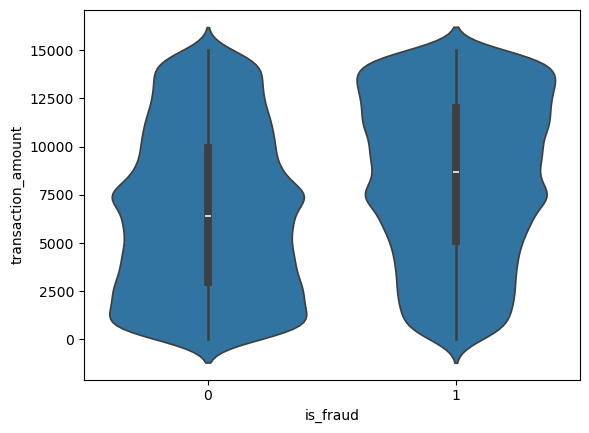

In [49]:
sns.violinplot(x='is_fraud',
               y='transaction_amount',
               data=df)

<Axes: xlabel='is_foreign_transaction', ylabel='count'>

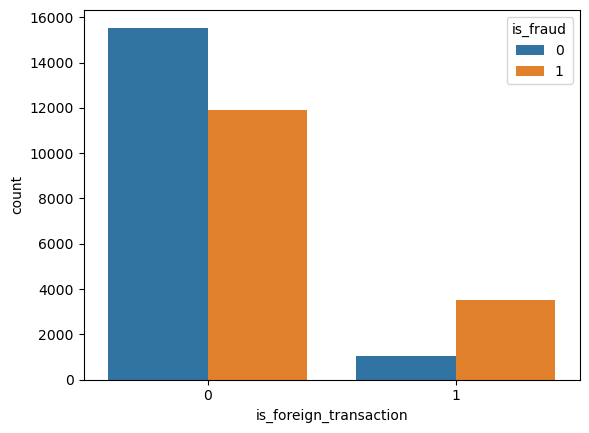

In [50]:
sns.countplot(x='is_foreign_transaction',
              hue='is_fraud',
              data=df)

# Model Selection : 

## - train test split

In [51]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41,2453.81,12686.50,21,0,9,0.0,2438.2,5.2,0
1,49,1574.12,36337.02,37,0,4,0.0,2967.1,8.4,1
2,38,14897.42,23295.64,21,0,0,0.0,4703.6,3.7,0
3,38,9927.23,38586.08,46,0,17,0.0,4281.2,5.5,1
4,61,12914.13,2013.73,34,0,11,0.0,4366.7,9.7,1


In [52]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## - Pipeline & Column Transformers

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [57]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [61]:
scale_cols = [
    'age',
    'transaction_amount',
    'account_balance',
    'num_transactions_today',
    'merchant_distance_km',
    'merchant_risk_score'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scale_cols)
    ],
    remainder='passthrough'
)

In [62]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42))
])

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC())
])

dt_pipeline = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])

rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

xgb_pipeline = Pipeline([
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

## - comparing using Cross Validation

In [63]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [64]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": logistic_pipeline,
    "KNN": knn_pipeline,
    "SVM": svm_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}


In [71]:
from sklearn.model_selection import cross_validate

scoring = {
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\n{name}")
    print(f"Mean F1      : {scores['test_f1'].mean():.4f}")
    print(f"Mean ROC-AUC : {scores['test_roc_auc'].mean():.4f}")
    print("-" * 40)


Logistic Regression
Mean F1      : 0.7265
Mean ROC-AUC : 0.8277
----------------------------------------

KNN
Mean F1      : 0.6257
Mean ROC-AUC : 0.7168
----------------------------------------

SVM
Mean F1      : 0.7217
Mean ROC-AUC : 0.8250
----------------------------------------

Decision Tree
Mean F1      : 0.6411
Mean ROC-AUC : 0.6534
----------------------------------------

Random Forest
Mean F1      : 0.7152
Mean ROC-AUC : 0.8097
----------------------------------------

XGBoost
Mean F1      : 0.7062
Mean ROC-AUC : 0.8034
----------------------------------------


## - HyperParameter Tuning on Top 4 Models


In [66]:
from sklearn.model_selection import RandomizedSearchCV

In [67]:
# Logistic Regrassion

In [72]:
logistic_params = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_params,
    n_iter=10,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

logistic_search.fit(X_train, y_train)

print(logistic_search.best_score_)
print(logistic_search.best_params_)

0.7267873702013095
{'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 0.01}


In [69]:
# SVM

In [77]:
svm_params = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf'],
    'model__gamma': ['scale', 0.1]
}

svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_params,
    n_iter=4,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

svm_search.fit(X_train, y_train)

print("Best F1:", svm_search.best_score_)
print("Best Parameters:", svm_search.best_params_)

Best F1: 0.7206212149431179
Best Parameters: {'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__C': 1}


In [78]:
# Random Forest

In [79]:
rf_params = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best F1:", rf_search.best_score_)
print("Best Parameters:")
print(rf_search.best_params_)

Best F1: 0.7243179333331056
Best Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 30}


In [80]:
xgb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best F1:", xgb_search.best_score_)
print("Best Parameters:")
print(xgb_search.best_params_)

Best F1: 0.7235837727207882
Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.9}


# Finale Model Evalution

## Logistic Regression

In [81]:
best_model = logistic_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.7522262146539603
Precision: 0.7527749747729566
Recall   : 0.7245063127225639
F1 Score : 0.7383701748597823
ROC AUC  : 0.8268903175206397
[[2577  735]
 [ 851 2238]]
              precision    recall  f1-score   support

           0       0.75      0.78      0.76      3312
           1       0.75      0.72      0.74      3089

    accuracy                           0.75      6401
   macro avg       0.75      0.75      0.75      6401
weighted avg       0.75      0.75      0.75      6401



# Model Exporting

In [85]:
import joblib


In [86]:
best_model = logistic_search.best_estimator_

joblib.dump(best_model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']